# Extreme Event Analysis

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from scipy import stats
# import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from src.common import mpl_apply
mpl_apply()

In [3]:
filepath = "../data/dtr_dataset.csv"
df = pd.read_csv(filepath)
df.head(3)

,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,LOCAL_DATE_dt,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,...,TOTAL_PRECIPITATION,TOTAL_RAIN,TOTAL_SNOW,SNOW_ON_GROUND,COOLING_DEGREE_DAYS,HEATING_DEGREE_DAYS,date,DTR,month,month_name
0,-52.742778,47.622222,ST JOHN'S A,8403506,8403506.2000.1.1,2000-01-01 00:00:00,2000-01-01,NL,2000,1,...,0.2,0.0,0.2,6.0,0.0,26.3,2000-01-01,8.1,1,Jan
1,-52.742778,47.622222,ST JOHN'S A,8403506,8403506.2000.1.2,2000-01-02 00:00:00,2000-01-02,NL,2000,1,...,0.4,0.0,0.4,6.0,0.0,21.9,2000-01-02,9.9,1,Jan
2,-52.742778,47.622222,ST JOHN'S A,8403506,8403506.2000.1.3,2000-01-03 00:00:00,2000-01-03,NL,2000,1,...,11.9,4.3,7.6,6.0,0.0,19.1,2000-01-03,12.8,1,Jan


In [4]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'LOCAL_DATE_dt', 'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH',
       'LOCAL_DAY', 'MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE',
       'TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'TOTAL_SNOW', 'SNOW_ON_GROUND',
       'COOLING_DEGREE_DAYS', 'HEATING_DEGREE_DAYS', 'date', 'DTR', 'month',
       'month_name'],
      dtype='object')

In [5]:
max_dtr = df[df.DTR == df.DTR.max()].iloc[0]
print(f"Max DTR: {max_dtr['DTR']}\n")

for col in max_dtr.index:
    print(f"{col}: {max_dtr[col]}")

Max DTR: 23.9

x: -52.78333888888889
y: 47.51335555555555
STATION_NAME: ST JOHNS WEST CLIMATE
CLIMATE_IDENTIFIER: 8403603
ID: 8403603.2017.2.8
LOCAL_DATE: 2017-02-08 00:00:00
LOCAL_DATE_dt: 2017-02-08
PROVINCE_CODE: NL
LOCAL_YEAR: 2017
LOCAL_MONTH: 2
LOCAL_DAY: 8
MEAN_TEMPERATURE: -6.1
MIN_TEMPERATURE: -18.0
MAX_TEMPERATURE: 5.9
TOTAL_PRECIPITATION: 7.4
TOTAL_RAIN: 0.6221949553959839
TOTAL_SNOW: 4.7650191608032255
SNOW_ON_GROUND: 31.0
COOLING_DEGREE_DAYS: 0.0
HEATING_DEGREE_DAYS: 24.1
date: 2017-02-08
DTR: 23.9
month: 2
month_name: Feb


In [6]:
min_dtr = df[df.DTR == df.DTR.min()].iloc[0]
print(f"Min DTR: {min_dtr['DTR']}\n")

for col in min_dtr.index:
    print(f"{col}: {min_dtr[col]}")

Min DTR: 0.2

x: -52.78333888888889
y: 47.51335555555555
STATION_NAME: ST JOHNS WEST CLIMATE
CLIMATE_IDENTIFIER: 8403603
ID: 8403603.2024.2.15
LOCAL_DATE: 2024-02-15 00:00:00
LOCAL_DATE_dt: 2024-02-15
PROVINCE_CODE: NL
LOCAL_YEAR: 2024
LOCAL_MONTH: 2
LOCAL_DAY: 15
MEAN_TEMPERATURE: 0.1
MIN_TEMPERATURE: 0.0
MAX_TEMPERATURE: 0.2
TOTAL_PRECIPITATION: 23.2
TOTAL_RAIN: 13.634653173117272
TOTAL_SNOW: 7.460189224862952
SNOW_ON_GROUND: 23.0
COOLING_DEGREE_DAYS: 0.0
HEATING_DEGREE_DAYS: 17.9
date: 2024-02-15
DTR: 0.2
month: 2
month_name: Feb


In [7]:
df[["STATION_NAME", "MAX_TEMPERATURE", "MIN_TEMPERATURE",
    "LOCAL_MONTH", 'LOCAL_YEAR']][df.DTR >= 20].tail(30)

,STATION_NAME,MAX_TEMPERATURE,MIN_TEMPERATURE,LOCAL_MONTH,LOCAL_YEAR
418,ST JOHN'S A,3.9,-16.1,2,2001
1841,ST JOHN'S A,13.0,-8.2,1,2005
2688,ST JOHN'S A,19.5,-0.8,5,2007
3306,ST JOHN'S A,7.2,-12.8,1,2009
3429,ST JOHN'S A,23.1,3.0,5,2009
5453,ST JOHNS WEST CLIMATE,3.1,-18.1,1,2015
5980,ST JOHNS WEST CLIMATE,22.7,1.8,6,2016
6214,ST JOHNS WEST CLIMATE,5.9,-18.0,2,2017
7795,ST JOHNS WEST CLIMATE,28.3,7.1,6,2021
8133,ST JOHNS WEST CLIMATE,20.5,-0.1,5,2022


#### Extreme high-DTR

In [8]:
# Calculate 90th percentile threshold
dtr_90th = df['DTR'].quantile(0.9)
print(f"90th percentile DTR threshold: {dtr_90th:.2f}")

# Define high-DTR extreme days
df['high_dtr_extreme'] = df['DTR'] > dtr_90th

# Summary
print(f"\nTotal high-DTR extreme days: {df['high_dtr_extreme'].sum()}")
print(
    f"Percentage of dataset: {(df['high_dtr_extreme'].sum() / len(df) * 100):.2f}%")

90th percentile DTR threshold: 12.90

Total high-DTR extreme days: 928
Percentage of dataset: 9.84%


In [9]:
df[df['high_dtr_extreme']][['date', 'DTR', 'MAX_TEMPERATURE', 'MIN_TEMPERATURE']]

,date,DTR,MAX_TEMPERATURE,MIN_TEMPERATURE
4,2000-01-05,15.6,15.0,-0.6
25,2000-01-26,14.3,13.6,-0.7
37,2000-02-07,13.7,0.4,-13.3
39,2000-02-09,15.5,3.1,-12.4
40,2000-02-10,13.1,2.3,-10.8
...,...,...,...,...
9371,2025-10-03,14.0,17.6,3.6
9374,2025-10-06,15.3,14.4,-0.9
9377,2025-10-09,15.0,20.2,5.2
9389,2025-10-21,13.2,13.4,0.2


In [10]:
# Calculate 10th percentile threshold
dtr_10th = df['DTR'].quantile(0.1)
print(f"10th percentile DTR threshold: {dtr_10th:.2f}")

# Define high-DTR extreme days
df['low_dtr_extreme'] = df['DTR'] < dtr_10th

# Print
print(f"\nTotal low-DTR extreme days: {df['low_dtr_extreme'].sum()}")
print(
    f"Percentage of dataset: {(df['low_dtr_extreme'].sum() / len(df) * 100):.2f}%")

10th percentile DTR threshold: 3.10

Total low-DTR extreme days: 932
Percentage of dataset: 9.88%


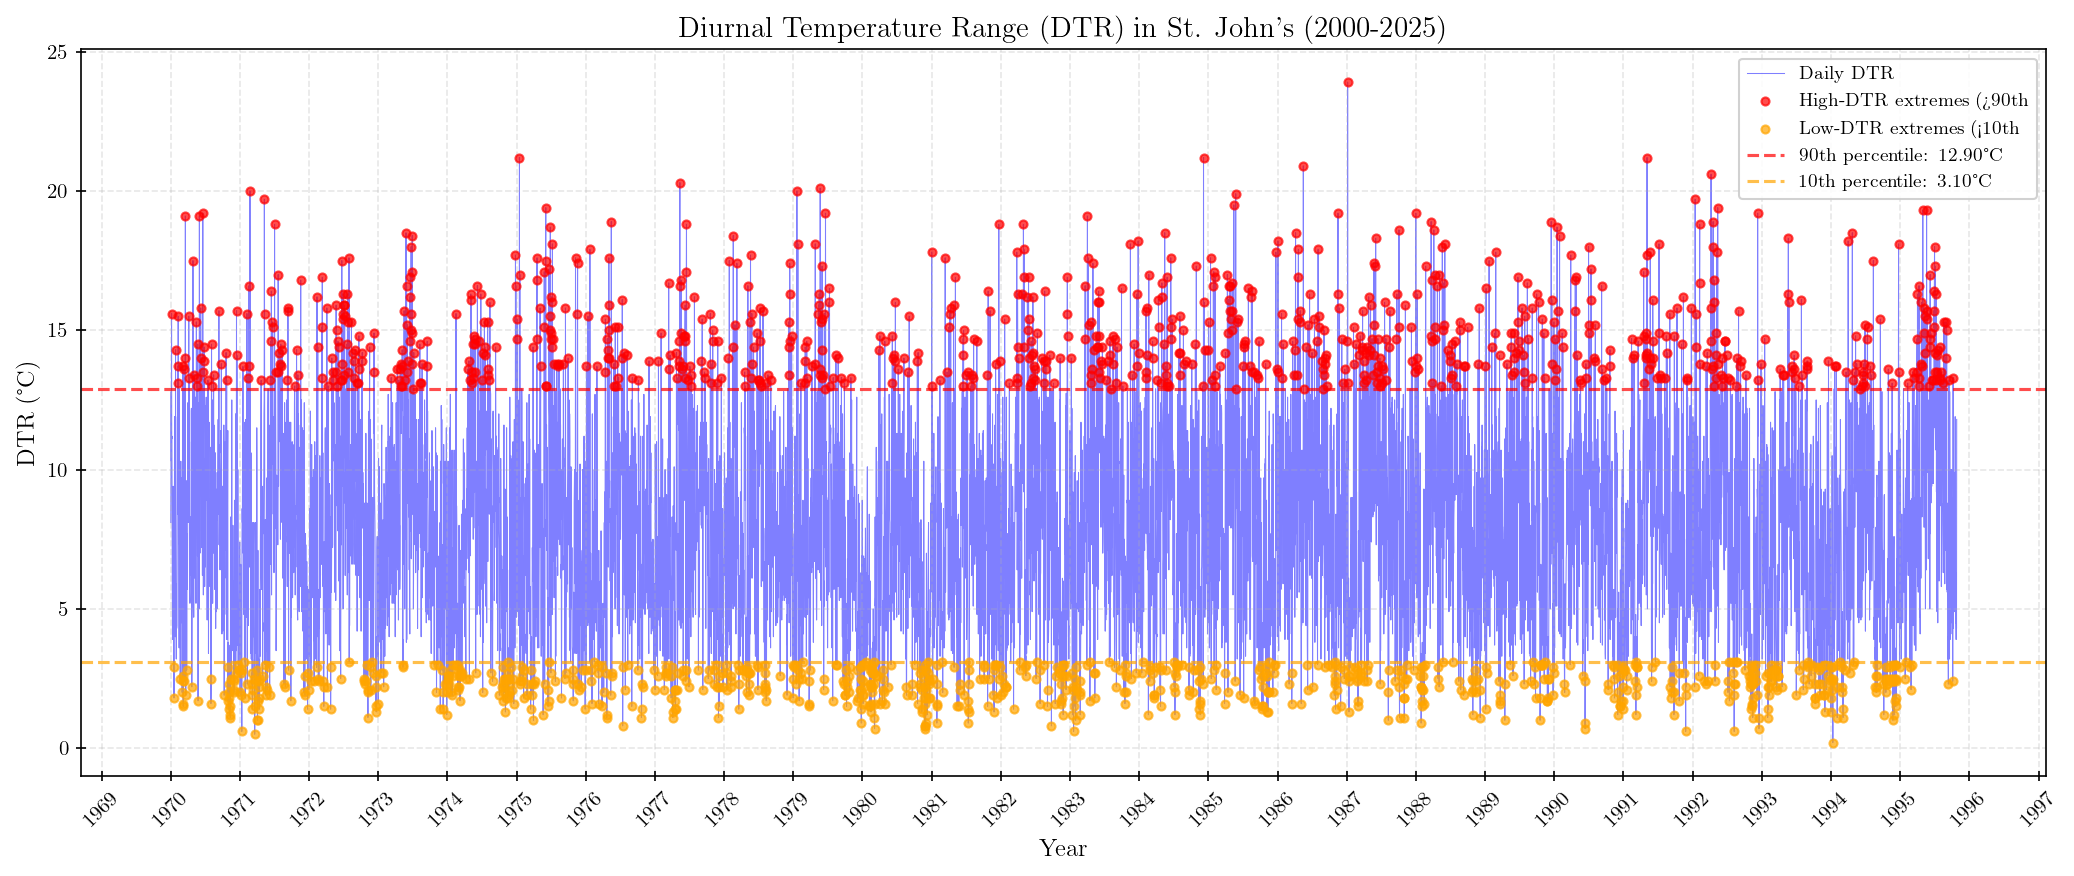

In [ ]:
# Create plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot all DTR values
ax.plot(df["date"], df["DTR"], color="blue", linewidth=0.5, alpha=0.5,
        label='Daily DTR', zorder=1)

# Highlight extreme values
high_extremes = df[df['high_dtr_extreme']]
low_extremes = df[df['low_dtr_extreme']]

ax.scatter(high_extremes["date"], high_extremes["DTR"],
           color='red', s=15, alpha=0.7, label=f'High-DTR extremes (>90th %ile)', zorder=3)
ax.scatter(low_extremes["date"], low_extremes["DTR"],
           color='orange', s=15, alpha=0.7, label=f'Low-DTR extremes (<10th %ile)', zorder=3)

# Add horizontal threshold lines
ax.axhline(dtr_90th, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'90th percentile: {dtr_90th:.2f}°C')
ax.axhline(dtr_10th, color='orange', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'10th percentile: {dtr_10th:.2f}°C')

# Labels and formatting
ax.set_title('Diurnal Temperature Range (DTR) in St. John\'s (2000-2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DTR (°C)', fontsize=12)

# Date formatting
ax.xaxis.set_major_locator(mdates.YearLocator(1))  # Every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Grid and legend
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

In [12]:
# Print statistics
print(f"90th percentile threshold: {dtr_90th:.2f}°C")
print(f"10th percentile threshold: {dtr_10th:.2f}°C")
print(f"Threshold range: {dtr_90th - dtr_10th:.2f}°C")
print(
    f"\nHigh-DTR extremes: {df['high_dtr_extreme'].sum()} days ({100*df['high_dtr_extreme'].sum()/len(df):.1f}%)")
print(
    f"Low-DTR extremes: {df['low_dtr_extreme'].sum()} days ({100*df['low_dtr_extreme'].sum()/len(df):.1f}%)")

90th percentile threshold: 12.90°C
10th percentile threshold: 3.10°C
Threshold range: 9.80°C

High-DTR extremes: 928 days (9.8%)
Low-DTR extremes: 932 days (9.9%)


#### Extremes count

In [13]:
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Count high and low extreme days per year
high_per_year = df[df['high_dtr_extreme']].groupby(df['date'].dt.year).size()
low_per_year = df[df['low_dtr_extreme']].groupby(df['date'].dt.year).size()

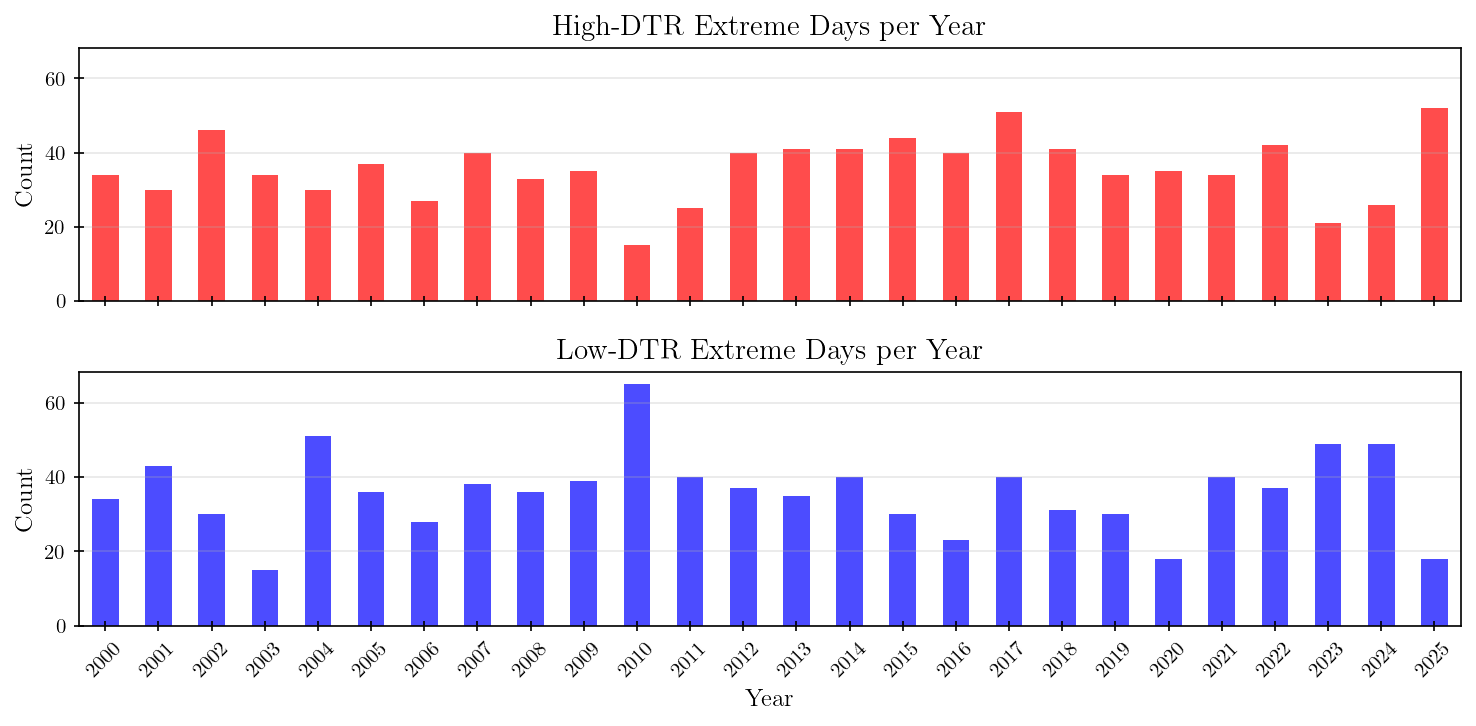

In [ ]:
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Count high and low extreme days per year
high_per_year = df[df['high_dtr_extreme']].groupby(df['date'].dt.year).size()
low_per_year = df[df['low_dtr_extreme']].groupby(df['date'].dt.year).size()

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, sharey=True)

# Plot high-DTR extremes
high_per_year.plot(kind='bar', color='red', alpha=0.7, ax=axes[0])
axes[0].set_title('High-DTR Extreme Days per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Plot low-DTR extremes
low_per_year.plot(kind='bar', color='blue', alpha=0.7, ax=axes[1])
axes[1].set_title('Low-DTR Extreme Days per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

## Trend Testing

#### Extreme DTR Trends?

In [15]:
# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Count high and low extreme days per year
high_per_year = df[df['high_dtr_extreme']].groupby(df['date'].dt.year).size()
low_per_year = df[df['low_dtr_extreme']].groupby(df['date'].dt.year).size()

# Prepare data for regression
years = high_per_year.index.values
high_counts = high_per_year.values
low_counts = low_per_year.values

# Linear regression for high extremes
slope_high, intercept_high, r_value_high, p_value_high, std_err_high = stats.linregress(
    years, high_counts)

# Linear regression for low extremes
slope_low, intercept_low, r_value_low, p_value_low, std_err_low = stats.linregress(
    years, low_counts)

# Calculate 95% confidence intervals
ci_high = 1.96 * std_err_high
ci_low = 1.96 * std_err_low

# Print results
print("HIGH-DTR EXTREMES:")
print(f"  Slope: {slope_high:.4f} days/year")
print(f"  95% CI: [{slope_high - ci_high:.4f}, {slope_high + ci_high:.4f}]")
print(f"  p-value: {p_value_high:.4f}")
print(f"  R²: {r_value_high**2:.4f}\n")

print("LOW-DTR EXTREMES:")
print(f"  Slope: {slope_low:.4f} days/year")
print(f"  95% CI: [{slope_low - ci_low:.4f}, {slope_low + ci_low:.4f}]")
print(f"  p-value: {p_value_low:.4f}")
print(f"  R²: {r_value_low**2:.4f}")

HIGH-DTR EXTREMES:
  Slope: 0.1764 days/year
  95% CI: [-0.2704, 0.6232]
  p-value: 0.4466
  R²: 0.0243

LOW-DTR EXTREMES:
  Slope: -0.0704 days/year
  95% CI: [-0.6419, 0.5011]
  p-value: 0.8112
  R²: 0.0024


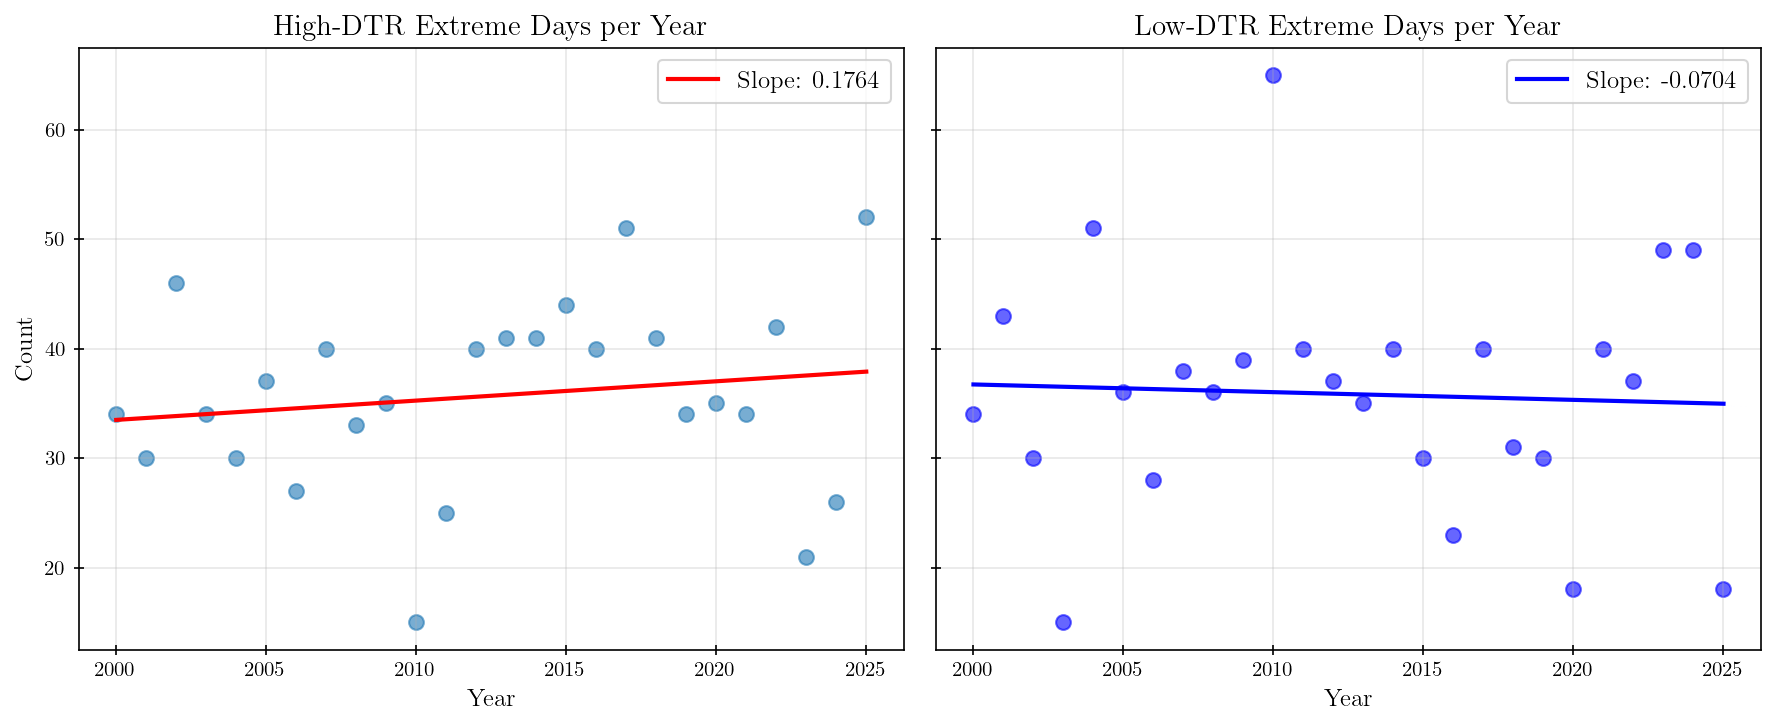

In [ ]:
# Plot with regression lines
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# High extremes
axes[0].scatter(years, high_counts, alpha=0.6, s=50)
axes[0].plot(years, slope_high * years + intercept_high, 'r-',
             linewidth=2, label=f'Slope: {slope_high:.4f}')
axes[0].set_title('High-DTR Extreme Days per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Low extremes
axes[1].scatter(years, low_counts, alpha=0.6, s=50, color='blue')
axes[1].plot(years, slope_low * years + intercept_low, 'b-',
             linewidth=2, label=f'Slope: {slope_low:.4f}')
axes[1].set_title('Low-DTR Extreme Days per Year')
axes[1].set_xlabel('Year')
# axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

#### Mann-Kendall tests

**Annual mean DTR**

Null Hypothesis: No monotonic trend exists.  
Alternate Hypothesis: One-sided monotonic trend exists (increasing trend)

A monotonic trend is one that consistently moves in a single direction either always increasing or always decreasing—without reversing.

MANN-KENDALL TEST: Annual Mean DTR (2000–2025)
Null hypothesis (H₀): No monotonic trend in DTR
Alternative hypothesis (H₁): Monotonic increasing trend

Kendall's τ: 0.1077
p-value (two-sided): 0.4574
p-value (one-sided, increasing): 0.2287
Significance level: α = 0.05

✗ FAIL TO REJECT null hypothesis
  Conclusion: No statistically significant monotonic trend (α=0.05).
  Random fluctuations dominate; no systematic directional change.


INTERPRETATION
Kendall's τ = 0.1077 (positive): Weak tendency toward increasing DTR

One-sided p-value = 0.2287:
  → This trend is NOT statistically significant at α=0.05
  → Cannot reject the null hypothesis of no monotonic trend


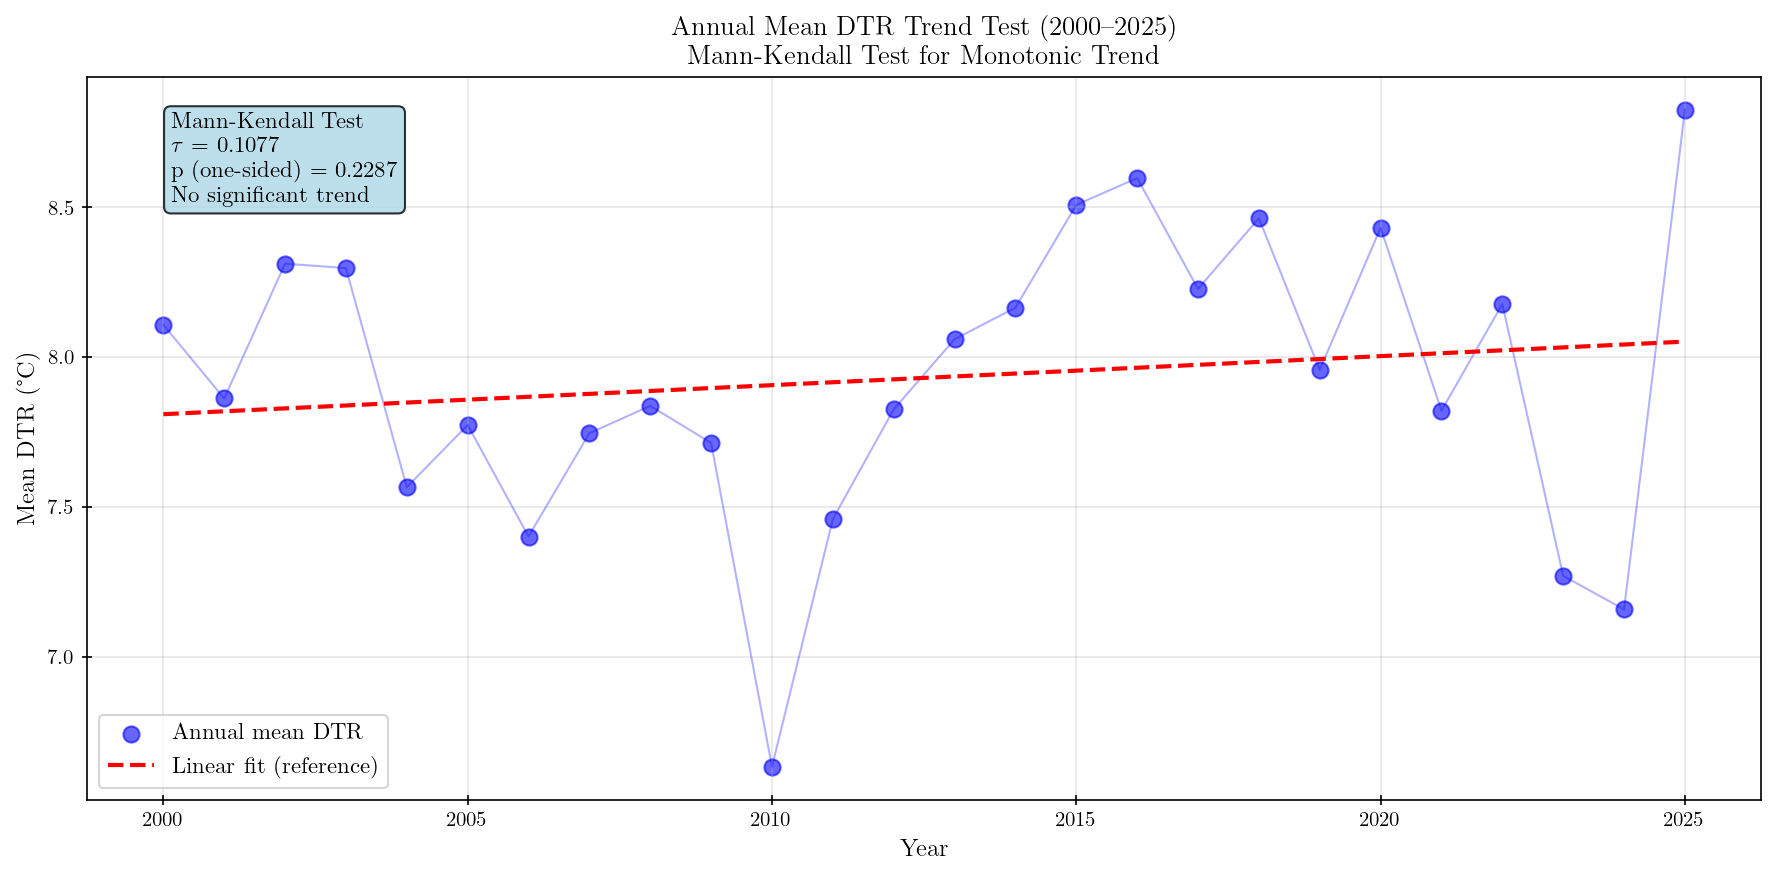

In [17]:
from scipy.stats import kendalltau
import numpy as np

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Compute annual mean DTR
annual_dtr = df.groupby(df['date'].dt.year)['DTR'].mean()
years = annual_dtr.index.values
dtr_values = annual_dtr.values

# ============================================================================
# MANN-KENDALL TEST FOR ANNUAL MEAN DTR
# ============================================================================
tau, p_value_two_sided = kendalltau(years, dtr_values)

# Convert to one-sided p-value (testing for increasing trend)
p_value_one_sided = p_value_two_sided / 2

print("="*70)
print("MANN-KENDALL TEST: Annual Mean DTR (2000–2025)")
print("="*70)
print(f"Null hypothesis (H₀): No monotonic trend in DTR")
print(f"Alternative hypothesis (H₁): Monotonic increasing trend\n")
print(f"Kendall's τ: {tau:.4f}")
print(f"p-value (two-sided): {p_value_two_sided:.4f}")
print(f"p-value (one-sided, increasing): {p_value_one_sided:.4f}")
print(f"Significance level: α = 0.05\n")

if p_value_one_sided < 0.05:
    print("✓ REJECT null hypothesis")
    if tau > 0:
        print(
            f"  Conclusion: Statistically significant INCREASING monotonic trend detected.")
    else:
        print(
            f"  Conclusion: Statistically significant DECREASING monotonic trend detected.")
else:
    print("✗ FAIL TO REJECT null hypothesis")
    print(f"  Conclusion: No statistically significant monotonic trend (α=0.05).")
    print(f"  Random fluctuations dominate; no systematic directional change.\n")

# ============================================================================
# INTERPRETATION
# ============================================================================
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
if tau > 0:
    print(
        f"Kendall's τ = {tau:.4f} (positive): Weak tendency toward increasing DTR")
else:
    print(
        f"Kendall's τ = {tau:.4f} (negative): Weak tendency toward decreasing DTR")

print(f"\nOne-sided p-value = {p_value_one_sided:.4f}:")
if p_value_one_sided < 0.05:
    print(f"  → This trend is statistically significant at α=0.05")
    if tau > 0:
        print(f"  → INCONSISTENT with global warming theory (DTR should decline)")
    else:
        print(f"  → CONSISTENT with global warming theory (DTR declining with warming)")
else:
    print(f"  → This trend is NOT statistically significant at α=0.05")
    print(f"  → Cannot reject the null hypothesis of no monotonic trend")

# ============================================================================
# VISUALIZATION
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(years, dtr_values, s=60, alpha=0.6,
           color='blue', label='Annual mean DTR')
ax.plot(years, dtr_values, 'b-', alpha=0.3, linewidth=1)

# Add trend line (for reference, not from Mann-Kendall)
z = np.polyfit(years, dtr_values, 1)
p = np.poly1d(z)
ax.plot(years, p(years), 'r--', linewidth=2, label='Linear fit (reference)')

# Annotation box
textstr = f'Mann-Kendall Test\n $\\tau$ = {tau:.4f}\np (one-sided) = {p_value_one_sided:.4f}'
if p_value_one_sided < 0.05:
    result = "Significant trend"
    box_color = 'lightcoral'
else:
    result = "No significant trend"
    box_color = 'lightblue'

textstr += f'\n{result}'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean DTR (°C)', fontsize=12)
ax.set_title(
    'Annual Mean DTR Trend Test (2000–2025)\nMann-Kendall Test for Monotonic Trend', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

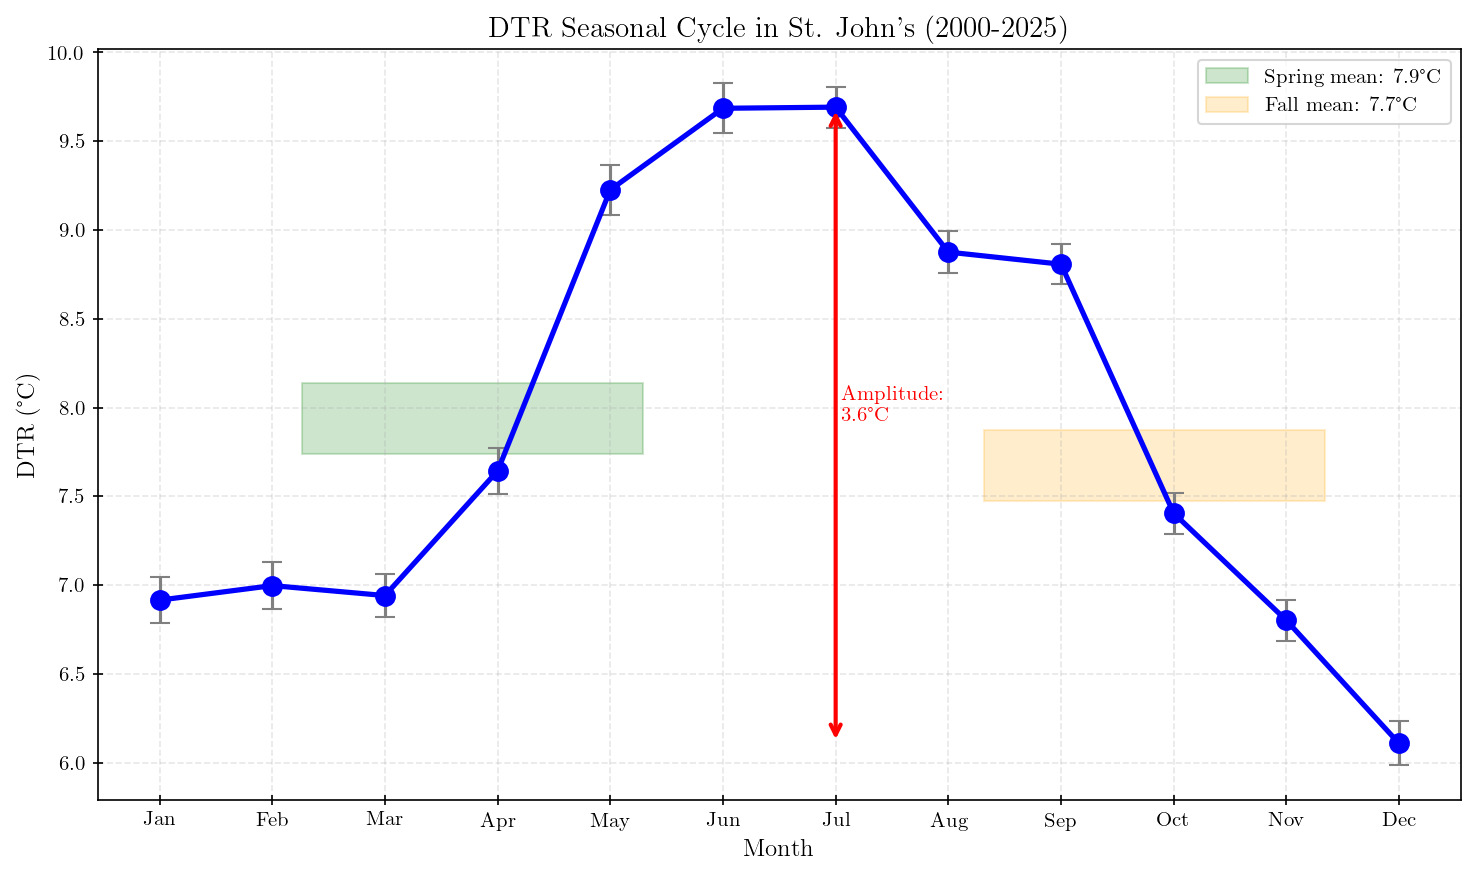

In [ ]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_stats = df.groupby(df['date'].dt.month)[
    'DTR'].agg(['mean', 'std', 'count'])
monthly_stats['sem'] = monthly_stats['std'] / np.sqrt(monthly_stats['count'])

fig, ax = plt.subplots(figsize=(10, 6))

# Main line plot
ax.errorbar(monthly_stats.index, monthly_stats['mean'],
            yerr=monthly_stats['sem'],
            fmt='o-', linewidth=2.5, markersize=9, capsize=5,
            color='blue', ecolor='gray', elinewidth=1.5)

# Highlight spring and fall
spring_months = [3, 4, 5]
fall_months = [9, 10, 11]

spring_mean = monthly_stats.loc[spring_months, 'mean'].mean()
fall_mean = monthly_stats.loc[fall_months, 'mean'].mean()

ax.axhspan(spring_mean - 0.2, spring_mean + 0.2, xmin=0.15, xmax=0.4,
           alpha=0.2, color='green', label=f'Spring mean: {spring_mean:.1f}°C')
ax.axhspan(fall_mean - 0.2, fall_mean + 0.2, xmin=0.65, xmax=0.9,
           alpha=0.2, color='orange', label=f'Fall mean: {fall_mean:.1f}°C')

# Annotate amplitude
max_month = monthly_stats['mean'].idxmax()
min_month = monthly_stats['mean'].idxmin()
amplitude = monthly_stats['mean'].max() - monthly_stats['mean'].min()

ax.annotate('', xy=(max_month, monthly_stats.loc[max_month, 'mean']),
            xytext=(max_month, monthly_stats.loc[min_month, 'mean']),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(max_month + 0.05, monthly_stats['mean'].mean(),
        f'Amplitude:\n{amplitude:.1f}°C',
        color='red', fontsize=10, fontweight='bold')

# Labels and styling
ax.set_title('DTR Seasonal Cycle in St. John\'s (2000-2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('DTR (°C)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

**High-extreme and low-extreme annual DTR counts**

Null Hypothesis: No monotonic trend exists.  
Alternate Hypothesis: One-sided monotonic trend exists (increasing trend)

Apply Mann-Kendall test separately to high-extreme and low-extreme annual counts.

In [19]:
from scipy.stats import kendalltau
import numpy as np

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Count high and low extreme days per year
high_per_year = df[df['high_dtr_extreme']].groupby(df['date'].dt.year).size()
low_per_year = df[df['low_dtr_extreme']].groupby(df['date'].dt.year).size()

years = high_per_year.index.values
high_counts = high_per_year.values
low_counts = low_per_year.values

# ============================================================================
# MANN-KENDALL TEST: HIGH-DTR EXTREMES
# ============================================================================
tau_high, p_value_high_two_sided = kendalltau(years, high_counts)
p_value_high_one_sided = p_value_high_two_sided / 2

print("="*70)
print("MANN-KENDALL TEST: High-DTR Extreme Days Annual Count (2000–2025)")
print("="*70)
print(f"Null hypothesis (H₀): No monotonic trend in high-DTR extremes")
print(f"Alternative hypothesis (H₁): Monotonic increasing trend\n")
print(f"Kendall's τ: {tau_high:.4f}")
print(f"p-value (two-sided): {p_value_high_two_sided:.4f}")
print(f"p-value (one-sided, increasing): {p_value_high_one_sided:.4f}")
print(f"Significance level: α = 0.05\n")

if p_value_high_one_sided < 0.05:
    print("✓ REJECT null hypothesis")
    if tau_high > 0:
        print(f"  Conclusion: Statistically significant INCREASING trend in high-DTR extremes.")
    else:
        print(f"  Conclusion: Statistically significant DECREASING trend in high-DTR extremes.")
else:
    print("✗ FAIL TO REJECT null hypothesis")
    print(f"  Conclusion: No statistically significant monotonic trend in high-DTR extremes.\n")

# ============================================================================
# MANN-KENDALL TEST: LOW-DTR EXTREMES
# ============================================================================
tau_low, p_value_low_two_sided = kendalltau(years, low_counts)
p_value_low_one_sided = p_value_low_two_sided / 2

print("\n" + "="*70)
print("MANN-KENDALL TEST: Low-DTR Extreme Days Annual Count (2000–2025)")
print("="*70)
print(f"Null hypothesis (H₀): No monotonic trend in low-DTR extremes")
print(f"Alternative hypothesis (H₁): Monotonic increasing trend\n")
print(f"Kendall's τ: {tau_low:.4f}")
print(f"p-value (two-sided): {p_value_low_two_sided:.4f}")
print(f"p-value (one-sided, increasing): {p_value_low_one_sided:.4f}")
print(f"Significance level: α = 0.05\n")

if p_value_low_one_sided < 0.05:
    print("✓ REJECT null hypothesis")
    if tau_low > 0:
        print(
            f"  Conclusion: Statistically significant INCREASING trend in low-DTR extremes.")
    else:
        print(
            f"  Conclusion: Statistically significant DECREASING trend in low-DTR extremes.")
else:
    print("✗ FAIL TO REJECT null hypothesis")
    print(f"  Conclusion: No statistically significant monotonic trend in low-DTR extremes.\n")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("SUMMARY: Mann-Kendall Results for Extreme Days")
print("="*70)
summary_data = {
    'Extreme Type': ['High-DTR', 'Low-DTR'],
    'Kendall τ': [f'{tau_high:.4f}', f'{tau_low:.4f}'],
    'p-value (one-sided)': [f'{p_value_high_one_sided:.4f}', f'{p_value_low_one_sided:.4f}'],
    'Significant (α=0.05)': ['Yes' if p_value_high_one_sided < 0.05 else 'No',
                             'Yes' if p_value_low_one_sided < 0.05 else 'No'],
    'Trend Direction': ['Increasing' if tau_high > 0 else 'Decreasing',
                        'Increasing' if tau_low > 0 else 'Decreasing']
}

for key in summary_data:
    print(f"{key:.<25} {summary_data[key][0]:>15} {summary_data[key][1]:>15}")

MANN-KENDALL TEST: High-DTR Extreme Days Annual Count (2000–2025)
Null hypothesis (H₀): No monotonic trend in high-DTR extremes
Alternative hypothesis (H₁): Monotonic increasing trend

Kendall's τ: 0.1541
p-value (two-sided): 0.2780
p-value (one-sided, increasing): 0.1390
Significance level: α = 0.05

✗ FAIL TO REJECT null hypothesis
  Conclusion: No statistically significant monotonic trend in high-DTR extremes.


MANN-KENDALL TEST: Low-DTR Extreme Days Annual Count (2000–2025)
Null hypothesis (H₀): No monotonic trend in low-DTR extremes
Alternative hypothesis (H₁): Monotonic increasing trend

Kendall's τ: 0.0063
p-value (two-sided): 0.9647
p-value (one-sided, increasing): 0.4823
Significance level: α = 0.05

✗ FAIL TO REJECT null hypothesis
  Conclusion: No statistically significant monotonic trend in low-DTR extremes.


SUMMARY: Mann-Kendall Results for Extreme Days
Extreme Type.............        High-DTR         Low-DTR
Kendall τ................          0.1541          0.0063
p-

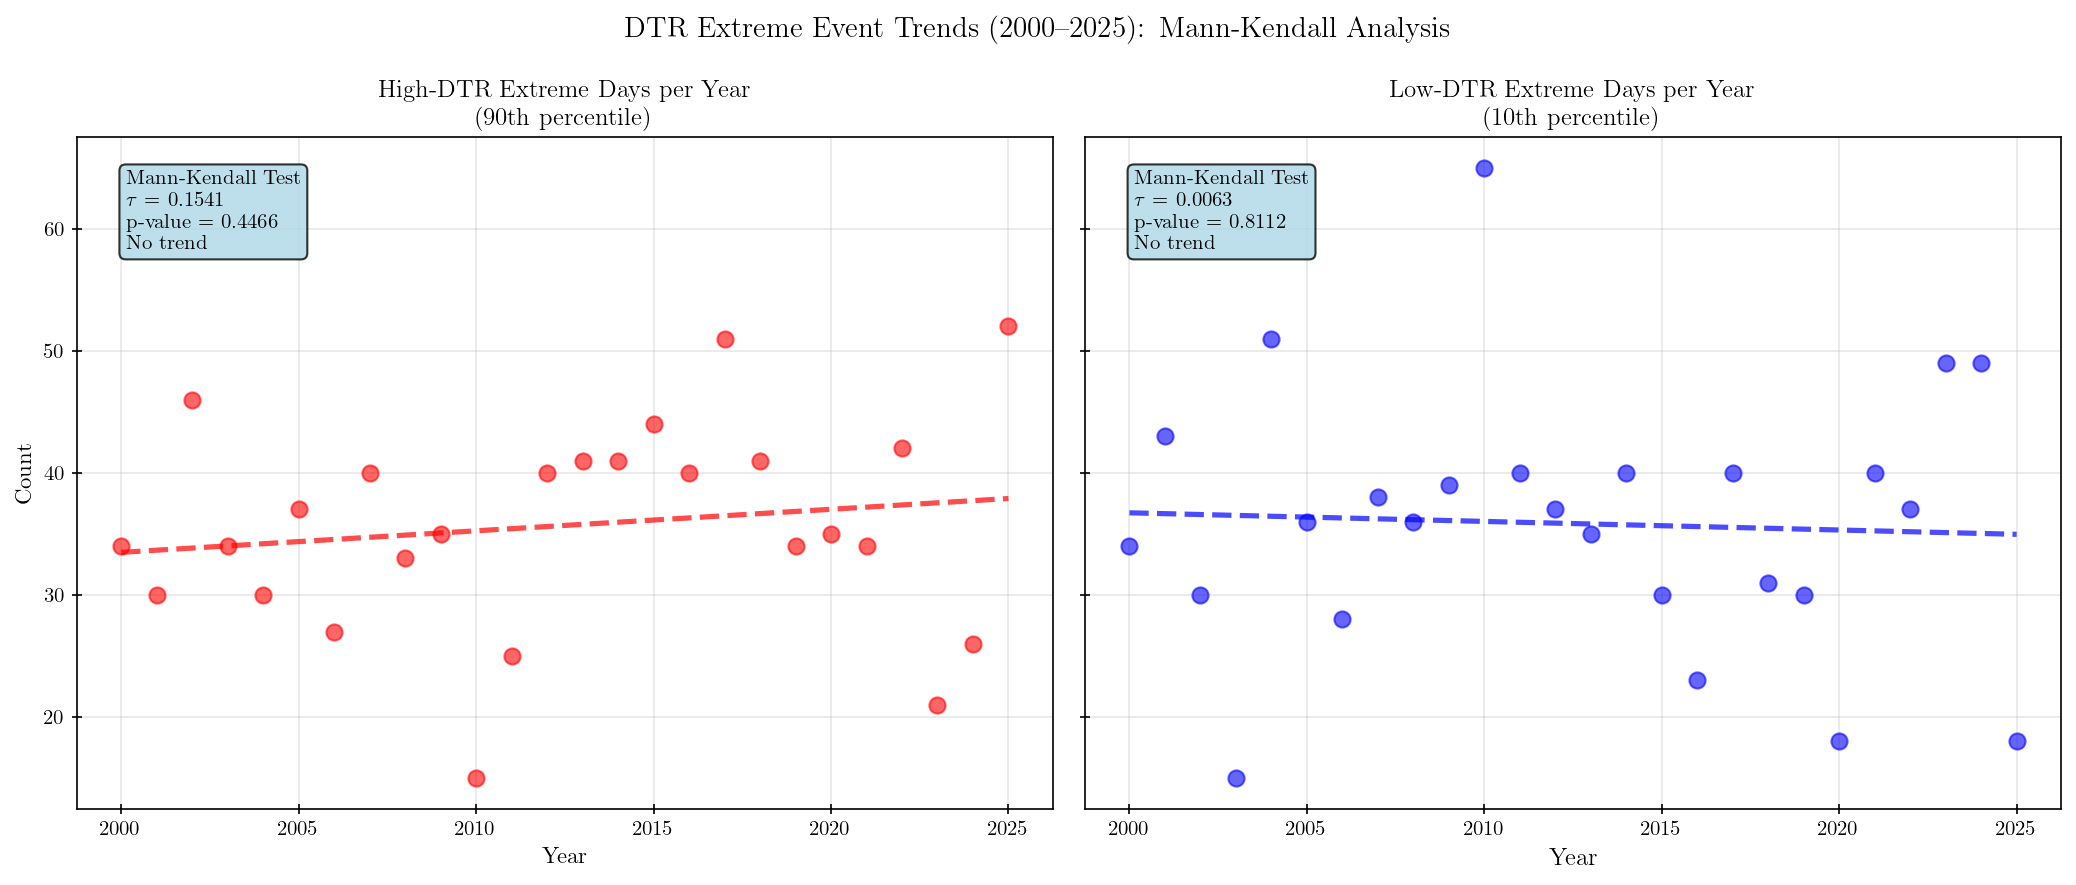

In [ ]:
from scipy.stats import kendalltau
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# [Your previous calculation code...]

# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# High extremes
axes[0].scatter(years, high_counts, alpha=0.6, s=60, color='red', zorder=3)
axes[0].plot(years, slope_high * years + intercept_high, 'r--',
             linewidth=2.5, alpha=0.7, zorder=2)

# Fix: Use $\tau$ instead of τ
textstr_high = (f'Mann-Kendall Test\n'
                f'$\\tau$ = {tau_high:.4f}\n'  # Changed here
                f'p-value = {p_value_high:.4f}\n')
if p_value_high < 0.05:
    result_high = f"{'↓' if tau_high < 0 else '↑'} Significant"
    box_color_high = 'lightcoral' if tau_high < 0 else 'lightgreen'
else:
    result_high = "No trend"
    box_color_high = 'lightblue'
textstr_high += result_high

axes[0].text(0.05, 0.95, textstr_high, transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor=box_color_high, alpha=0.8))

axes[0].set_title('High-DTR Extreme Days per Year\n(90th percentile)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Low extremes
axes[1].scatter(years, low_counts, alpha=0.6, s=60, color='blue', zorder=3)
axes[1].plot(years, slope_low * years + intercept_low, 'b--',
             linewidth=2.5, alpha=0.7, zorder=2)

textstr_low = (f'Mann-Kendall Test\n'
               f'$\\tau$ = {tau_low:.4f}\n'
               f'p-value = {p_value_low:.4f}\n')
if p_value_low < 0.05:
    result_low = f"{'↑' if tau_low > 0 else '↓'} Significant"
    box_color_low = 'lightgreen' if tau_low > 0 else 'lightcoral'
else:
    result_low = "No trend"
    box_color_low = 'lightblue'
textstr_low += result_low

axes[1].text(0.05, 0.95, textstr_low, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor=box_color_low, alpha=0.8))

axes[1].set_title('Low-DTR Extreme Days per Year\n(10th percentile)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].grid(True, alpha=0.3)

fig.suptitle('DTR Extreme Event Trends (2000–2025): Mann-Kendall Analysis',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()